In [1]:
import pandas as pd
from skbio import OrdinationResults
from joint_rpca_functions import (subject_boxplot, extract_feature_loadings,
                                  find_log_ratios, plot_log_ratios)
from joint_rpca_output_preprocessing import (misame_meta_add_cols, vital_meta_add_cols,
                                             load_misame_raw_tables, load_vital_raw_tables)

%matplotlib inline

## Figure 2E

### MISAME

In [2]:
#metadata
misame_metadata = pd.read_csv('../../../Data/MISAME/metadata/misame_processed_metadata.tsv', sep='\t', index_col=0)
misame_metadata = misame_meta_add_cols(misame_metadata)

In [3]:
#load Joint-RPCA results
ord_misame = OrdinationResults.read('../output/all_tps/misame_ord_with_untarg_sapient_final.txt')
ord_misame_samples = ord_misame.samples.rename(columns={0:'PC1', 1:'PC2', 2:'PC3', 3:'PC4'})

#create dict with proportione explained
prop_explained_misame = {}
for i, prop in enumerate(ord_misame.proportion_explained):
    prop_explained_misame["PC" + str(i+1)] = round(prop*100, 2)
print("With sapient subset:", prop_explained_misame)

#create df for plotting
ord_misame_plt_ = pd.concat([ord_misame_samples, misame_metadata], axis=1, sort=True)
ord_misame_plt_['BEP'] = ord_misame_plt_['BEP'].astype('category')

With sapient subset: {'PC1': 50.83, 'PC2': 49.04, 'PC3': 0.12}


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

>0 vs. <-1: Mann-Whitney-Wilcoxon test two-sided, P_val:4.243e-02 U_stat=2.697e+04


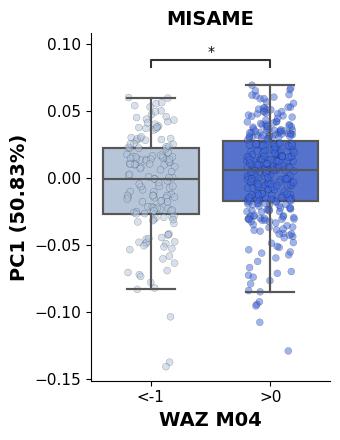

In [4]:
phenotype = 'WAZ_M04_wide_margin_pub'
order_=["<-1", ">0"]
pc='PC1'

subject_boxplot(plot_df=ord_misame_plt_, x_=phenotype, y_=pc, order_=order_, 
                palette_={order_[0]: 'lightsteelblue', order_[1]: 'royalblue'}, 
                prop_explained_=prop_explained_misame,
                xlabel_='WAZ M04', title_='MISAME', save_fig=False, 
                save_path='../../../Figures/Joint-RPCA/MISAME_WAZ_M4_GAP_boxplot_{}.pdf'.format(pc))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Yes vs. No: Mann-Whitney-Wilcoxon test two-sided, P_val:1.541e-03 U_stat=9.359e+04


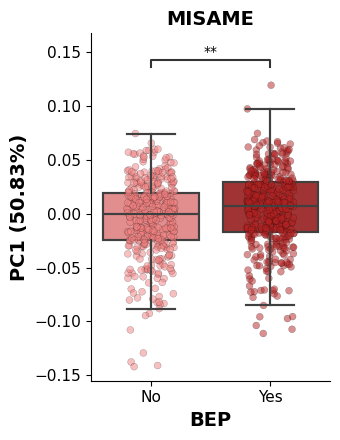

In [5]:
phenotype = 'BEP_pub'
order_=["No", "Yes"]
pc='PC1'

subject_boxplot(plot_df=ord_misame_plt_, x_=phenotype, y_=pc, order_=order_, 
                palette_={order_[0]: 'lightcoral', order_[1]: 'firebrick'}, 
                prop_explained_=prop_explained_misame,
                xlabel_='BEP', title_='MISAME', save_fig=False, 
                save_path='../../../Figures/Joint-RPCA/MISAME_BEP_boxplot_{}.pdf'.format(pc))

### Mumta-LW

In [6]:
#metadata
vital_metadata = pd.read_csv('../../../Data/VITAL/metadata/vital_processed_metadata.tsv', sep='\t', index_col=0)
vital_metadata = vital_meta_add_cols(vital_metadata)

In [7]:
#load Joint-RPCA results
ord_vital = OrdinationResults.read('../output/all_tps/vital_ord_with_untarg_sapient_v3.txt')

#create dict with proportione explained
prop_explained_vital = {}
for i, prop in enumerate(ord_vital.proportion_explained):
    prop_explained_vital["PC" + str(i+1)] = round(prop*100, 2)
print("With sapient subset:", prop_explained_vital)

#create df for plotting
ord_vital_samples = ord_vital.samples.rename(columns={0:'PC1', 1:'PC2', 2:'PC3'})
ord_vital_plt_ = pd.concat([ord_vital_samples, vital_metadata], axis=1, sort=True)

With sapient subset: {'PC1': 58.12, 'PC2': 41.72, 'PC3': 0.17}


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

>-1 vs. <-2: Mann-Whitney-Wilcoxon test two-sided, P_val:2.848e-03 U_stat=5.611e+03


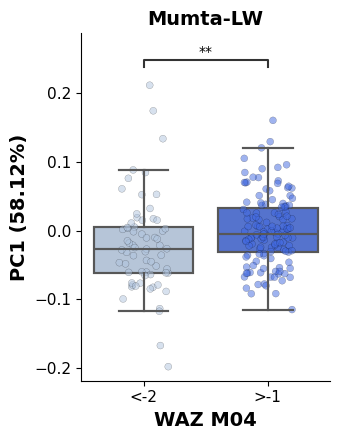

In [8]:
phenotype = 'WAZ_M04_wide_margin_pub'
order_ = ["<-2", ">-1"]
pc='PC1'

subject_boxplot(plot_df=ord_vital_plt_, x_=phenotype, y_=pc, order_=order_, 
                palette_={order_[0]: 'lightsteelblue', order_[1]: 'royalblue'}, 
                prop_explained_=prop_explained_vital,
                xlabel_='WAZ M04', title_='Mumta-LW', save_fig=False, 
                save_path='../../../Figures/Joint-RPCA/VITAL_WAZ_M4_GAP_boxplot_{}.pdf'.format(pc))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Yes vs. No: Mann-Whitney-Wilcoxon test two-sided, P_val:4.029e-03 U_stat=1.181e+04


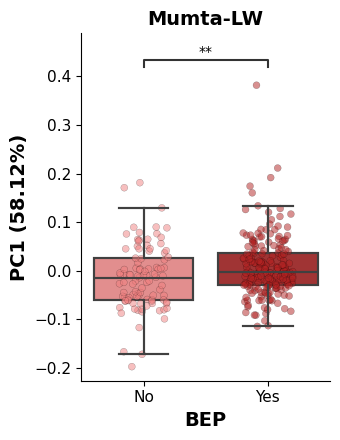

In [9]:
phenotype = 'BEP_pub'
order_=["No", "Yes"]
pc='PC1'

subject_boxplot(plot_df=ord_vital_plt_, x_=phenotype, y_=pc, order_=order_, 
                palette_={order_[0]: 'lightcoral', order_[1]: 'firebrick'}, 
                prop_explained_=prop_explained_vital,
                xlabel_='BEP', title_='Mumta-LW', save_fig=False, 
                save_path='../../../Figures/Joint-RPCA/VITAL_BEP_boxplot_{}.pdf'.format(pc))

## Figure 2F

### MISAME

In [12]:
#extract misame feature loadings
tables_misame_all = load_misame_raw_tables()
ord_misame_feats = ord_misame.features.copy()
axis_use = 'PC1'
modality_lst = ['micro', 'hmo', 'biocrates', 'untargeted_sapient']

feature_tables_misame = extract_feature_loadings(ord_misame, tables_misame_all, 
                                                 axis_use=axis_use, modalities=modality_lst)

In [13]:
log_ratios_sapient = find_log_ratios(tables_misame_all, feature_tables_misame, 
                                     axis_use=axis_use, quantile=0.9, nfeatures=5)

Micro num:  ['B6', 'PA', 'Bio', 'B2', 'B1']
Micro num:  ['K', 'Fe', 'Cu', 'Na', 'Se']

HMO num:  ['3FL', 'FDSLNH', 'LNFP II', "2'FL", 'LNnT']
HMO den:  ['DSLNH', "6'SL", 'DSLNT', 'LSTc', 'Sia']

biocrates Top quantile:  0.06
biocrates Bottom quantile:  -0.06
Numerator: (47,)
Denominator: (47,)

untargeted_sapient Top quantile:  0.03
untargeted_sapient Bottom quantile:  -0.02
Numerator: (11,)
Denominator: (11,)



micro
Timepoint: 1 pvalue: 0.0
Timepoint: 2 pvalue: 0.0
Timepoint: 3 pvalue: 0.0
hmo
Timepoint: 1 pvalue: 0.0376
Timepoint: 2 pvalue: 0.1753
Timepoint: 3 pvalue: 0.032
biocrates
Timepoint: 1 pvalue: 0.0349
Timepoint: 2 pvalue: 0.027
Timepoint: 3 pvalue: 0.0051
untargeted_sapient
Timepoint: 1 pvalue: 0.0001
Timepoint: 2 pvalue: 0.0
Timepoint: 3 pvalue: 0.0


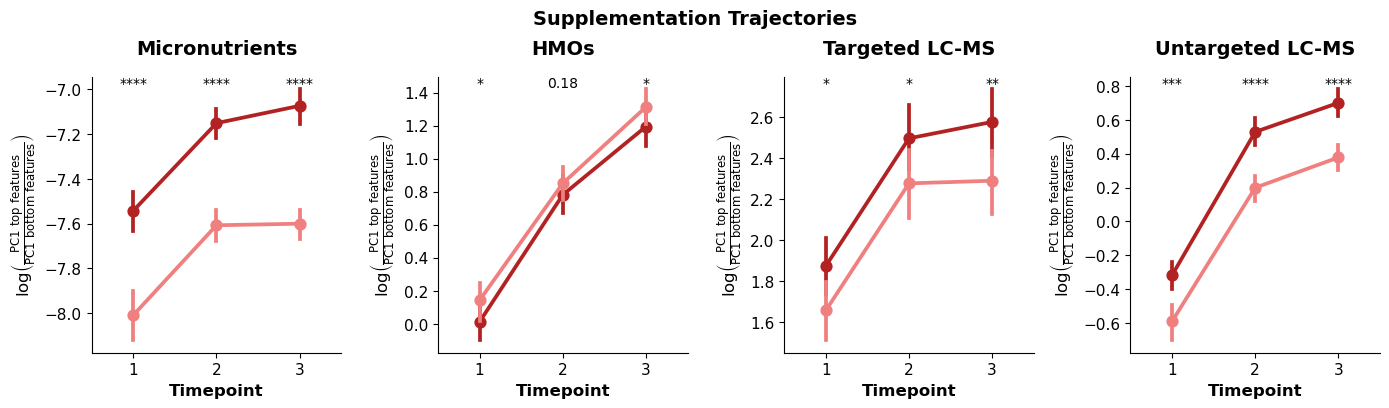

In [14]:
plot_log_ratios(log_ratios_sapient, misame_metadata, phenotype='BEP_pub', timepoint='Timepoint',
                modality_lst = ['micro', 'hmo', 'biocrates', 'untargeted_sapient'], hue_order = ['Yes','No'],
                legend_labels = None, legend_title = 'Postnatal BEP', legend_loc='lower right', palette = ['firebrick', 'lightcoral'],
                plot_subtitle = 'Supplementation Trajectories', axis_use='PC1', make_legend=False, markeredgecolor='black',
                savefig=False, save_path='../../../Figures/Joint-RPCA/MISAME_BEP_trajectories_PC1.pdf')

micro
Timepoint: 1 pvalue: 0.0626
Timepoint: 2 pvalue: 0.3241
Timepoint: 3 pvalue: 0.2991
hmo
Timepoint: 1 pvalue: 0.1258
Timepoint: 2 pvalue: 0.1692
Timepoint: 3 pvalue: 0.4163
biocrates
Timepoint: 1 pvalue: 0.0307
Timepoint: 2 pvalue: 0.5089
Timepoint: 3 pvalue: 0.3129
untargeted_sapient
Timepoint: 1 pvalue: 0.0
Timepoint: 2 pvalue: 0.1754
Timepoint: 3 pvalue: 0.0031


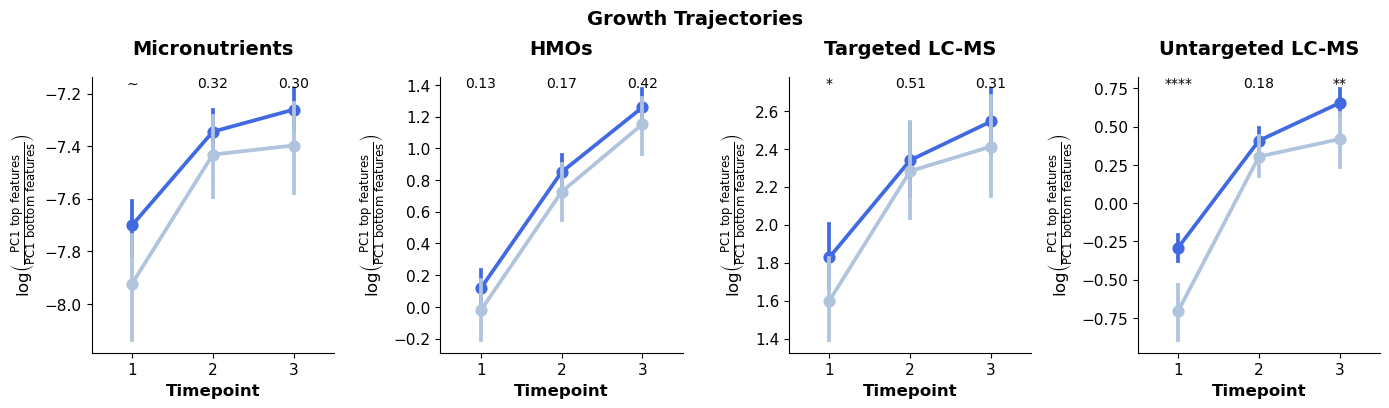

In [15]:
plot_log_ratios(log_ratios_sapient, misame_metadata, phenotype='WAZ_M04_wide_margin', timepoint='Timepoint',
                modality_lst = ['micro', 'hmo', 'biocrates', 'untargeted_sapient'], hue_order=[0.0, 1.0],
                legend_labels = {'1.0':'<-1', '0.0':'>0'}, legend_title = 'WAZ M04', legend_loc='lower right',
                plot_subtitle = 'Growth Trajectories', axis_use='PC1', make_legend=False, palette=['royalblue','lightsteelblue'],
                savefig=False, save_path='../../../Figures/Joint-RPCA/MISAME_WAZ-M04_trajectories_PC1.pdf')

### Mumta-LW

In [16]:
#extract vital feature loadings
tables_vital_all = load_vital_raw_tables()
ord_vital_feats = ord_vital.features.copy()
axis_use = 'PC1'
modality_lst = ['micro', 'hmo', 'biocrates', 'untargeted_sapient']

feature_tables_vital = extract_feature_loadings(ord_vital, tables_vital_all, 
                                                axis_use=axis_use, modalities=modality_lst)

In [17]:
log_ratios_vital = find_log_ratios(tables_vital_all, feature_tables_vital, nfeatures=5, 
                                   nhmos=5, axis_use='PC1', quantile=0.9)

Micro num:  ['g-tocopherol', 'P ', 'PA', 'Bio', 'B2']
Micro num:  ['Fe', 'Se', 'B12', 'As', 'Na']

HMO num:  ['FLNH', 'DFLNH', 'DFLNT', "2'FL", '3FL']
HMO den:  ['DSLNT', "3'SL", 'LSTc', 'LSTb', 'LNFP III']

biocrates Top quantile:  0.06
biocrates Bottom quantile:  -0.04
Numerator: (47,)
Denominator: (47,)

untargeted_sapient Top quantile:  -0.03
untargeted_sapient Bottom quantile:  -0.05
Numerator: (11,)
Denominator: (11,)



micro
Timepoint: 1 pvalue: 0.051
Timepoint: 2 pvalue: 0.1784
hmo
Timepoint: 1 pvalue: 0.0372
Timepoint: 2 pvalue: 0.0901
biocrates
Timepoint: 1 pvalue: 0.0
Timepoint: 2 pvalue: 0.3033
untargeted_sapient
Timepoint: 1 pvalue: 0.0
Timepoint: 2 pvalue: 0.0196


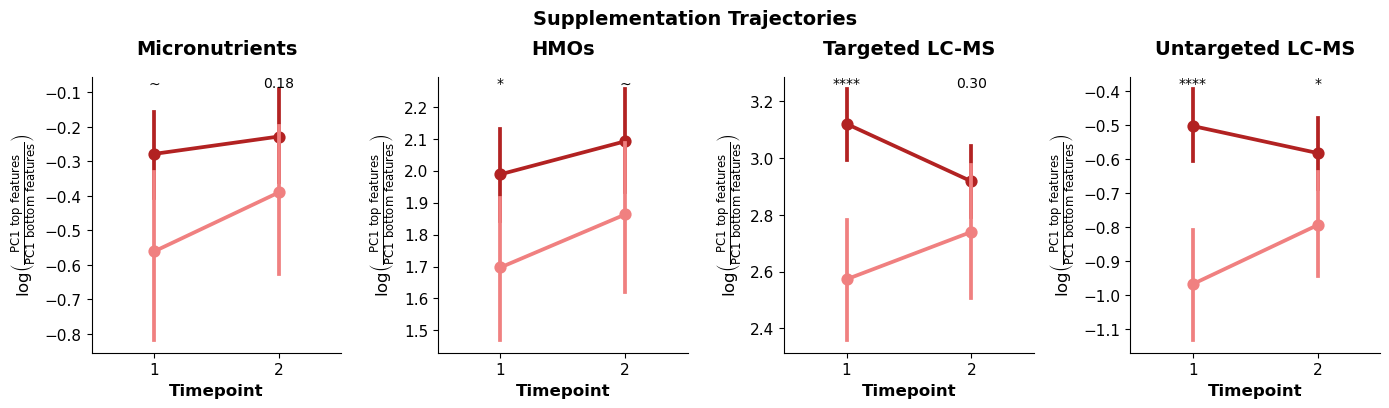

In [18]:
plot_log_ratios(log_ratios_vital, vital_metadata, phenotype='BEP_pub', timepoint='Timepoint',
                modality_lst = ['micro', 'hmo', 'biocrates', 'untargeted_sapient'], axis_use = 'PC1',
                legend_labels = None, legend_title = 'BEP', legend_loc = 'lower right', hue_order = ['Yes','No'],
                plot_subtitle = 'Supplementation Trajectories', make_legend = False, palette = ['firebrick', 'lightcoral'],
                savefig=False, save_path='../../../Figures/Joint-RPCA/VITAL_BEP_trajectories_PC1.pdf')

micro
Timepoint: 1 pvalue: 0.0078
Timepoint: 2 pvalue: 0.0168
hmo
Timepoint: 1 pvalue: 0.0989
Timepoint: 2 pvalue: 0.2967
biocrates
Timepoint: 1 pvalue: 0.0099
Timepoint: 2 pvalue: 0.1356
untargeted_sapient
Timepoint: 1 pvalue: 0.0
Timepoint: 2 pvalue: 0.0068


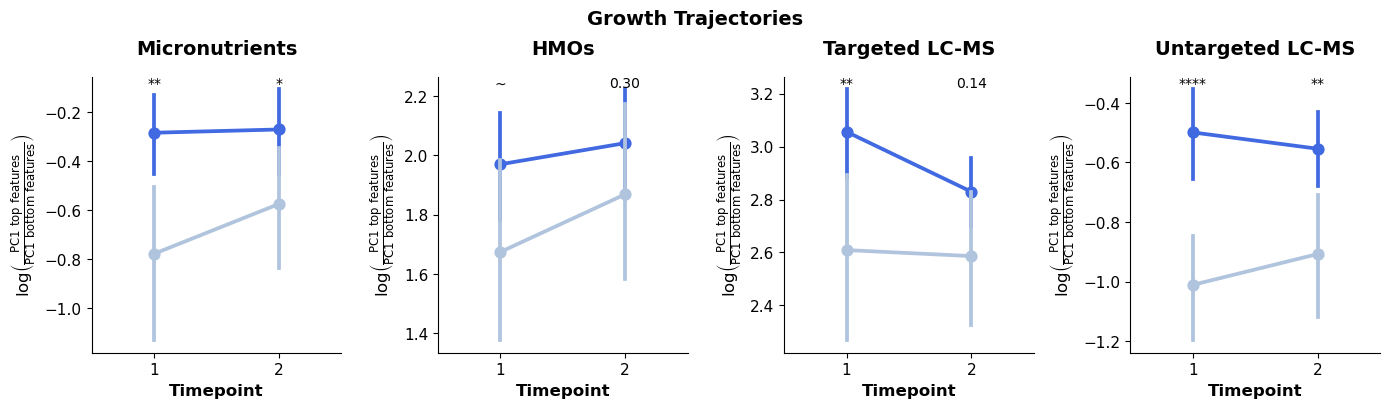

In [19]:
plot_log_ratios(log_ratios_vital, vital_metadata, phenotype='WAZ_M04_wide_margin', timepoint='Timepoint',
                modality_lst = ['micro', 'hmo', 'biocrates', 'untargeted_sapient'], hue_order=[0.0, 1.0],
                legend_labels = {'1.0':'<-2', '0.0':'>-1'}, legend_title = 'WAZ M04', legend_loc='lower right',
                plot_subtitle = 'Growth Trajectories', axis_use='PC1', make_legend=False, palette=['royalblue','lightsteelblue'],
                savefig=False, save_path='../../../Figures/Joint-RPCA/VITAL_WAZ-M04_trajectories_PC1.pdf')